In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.drop_duplicates(inplace=True)

df['director'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df.dropna(inplace=True)

In [4]:
print(df.info())

print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
Index: 8702 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8702 non-null   object        
 1   type          8702 non-null   object        
 2   title         8702 non-null   object        
 3   director      8702 non-null   object        
 4   cast          8702 non-null   object        
 5   country       8702 non-null   object        
 6   date_added    8702 non-null   datetime64[ns]
 7   release_year  8702 non-null   int64         
 8   rating        8702 non-null   object        
 9   duration      8702 non-null   object        
 10  listed_in     8702 non-null   object        
 11  description   8702 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 883.8+ KB
None
       show_id   type                 title director           cast  \
count     8702   8702                  8702     87

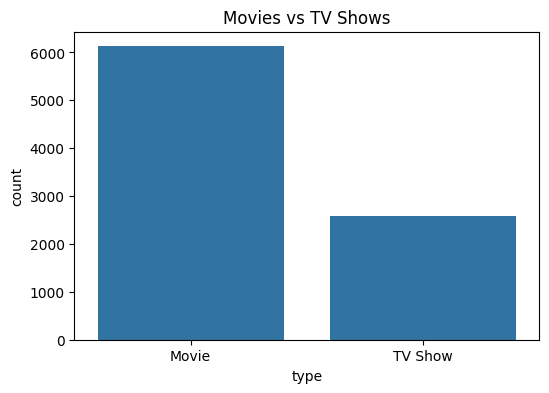

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")

plt.show()

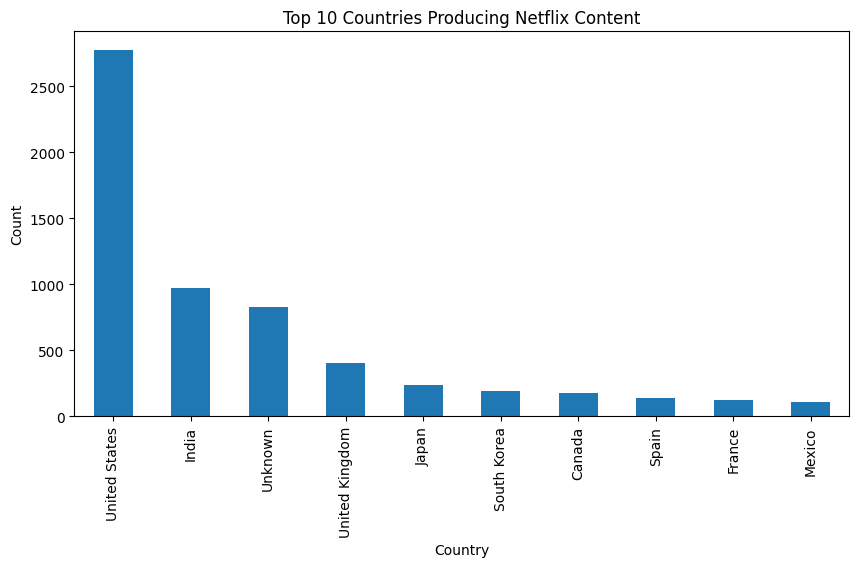

In [6]:
plt.figure(figsize=(10,5))

top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title("Top 10 Countries Producing Netflix Content")

plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

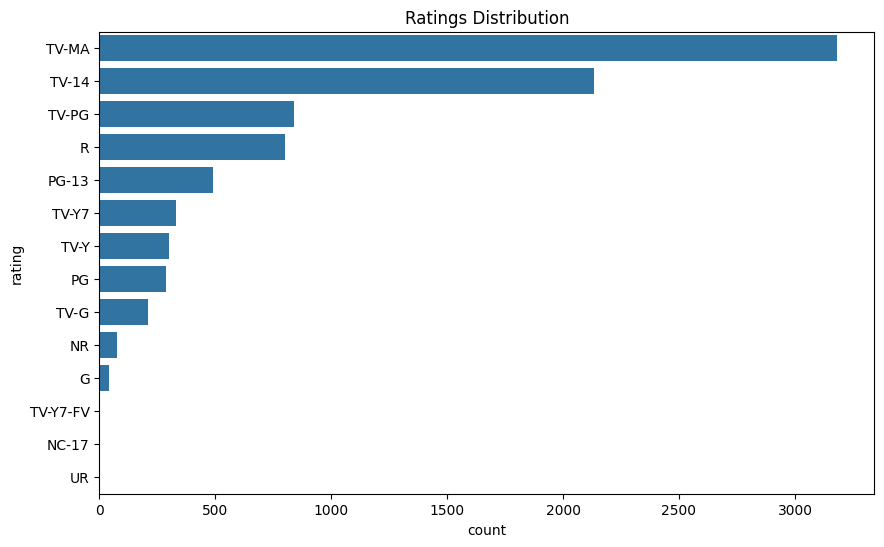

In [7]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Ratings Distribution")

plt.show()

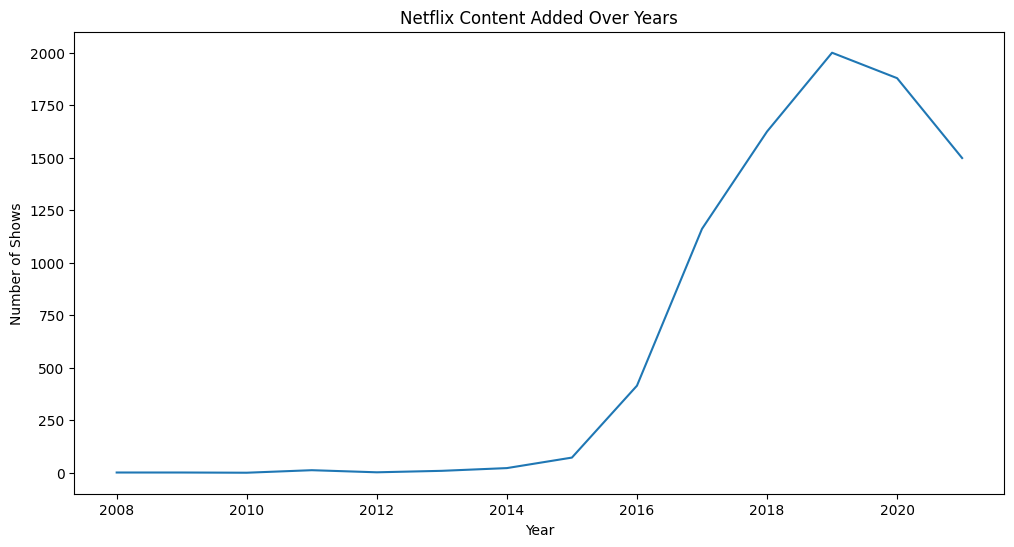

In [8]:
df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(12,6))

df['year_added'].value_counts().sort_index().plot(kind='line')

plt.title("Netflix Content Added Over Years")

plt.xlabel("Year")
plt.ylabel("Number of Shows")

plt.show()

In [9]:
df['type_encoded'] = df['type'].map({
    'Movie': 0,
    'TV Show': 1
})

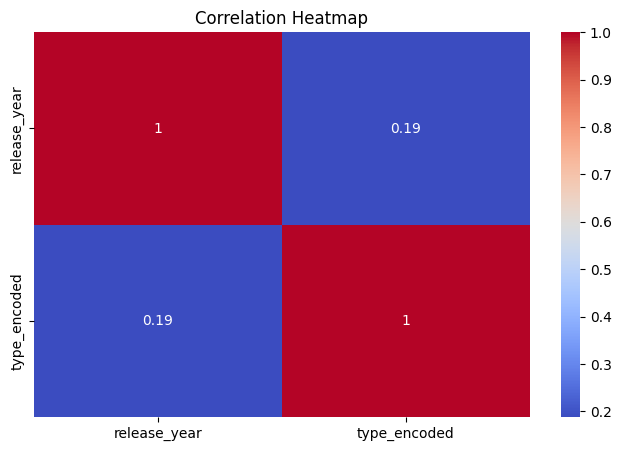

In [10]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['release_year', 'type_encoded']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Conclusion

- Netflix contains significantly more Movies than TV Shows.
- USA contributes the highest amount of Netflix content.
- TV-MA is the most common rating category.
- Netflix content increased rapidly after 2015.
- International and Drama genres are highly dominant.
- EDA helped uncover important trends and patterns in the dataset.